In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# Load the original dataset
df = pd.read_csv("titanic.csv")

# Remove the column with very high missingness
df = df.drop(columns=["deck"])

# Remove rows with missing embarkation information
df = df.dropna(
    subset=["embarked", "embark_town"]
)

print("Dataset shape:", df.shape)
print("Missing ages:", df["age"].isna().sum())

features = [
    "pclass", "sex", "age", "sibsp",
    "parch", "fare", "embarked"
]

X = df[features]
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Class balance:")
print(y.value_counts(normalize=True) * 100)

Training rows: 711
Testing rows: 178
Class balance:
survived
0    61.754781
1    38.245219
Name: proportion, dtype: float64


In [2]:
numeric_features = [
    "pclass", "age", "sibsp", "parch", "fare"
]

categorical_features = ["sex", "embarked"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=4,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

pipelines = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)
    pipelines[name] = pipeline

    print(name, "trained successfully")

Logistic Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully


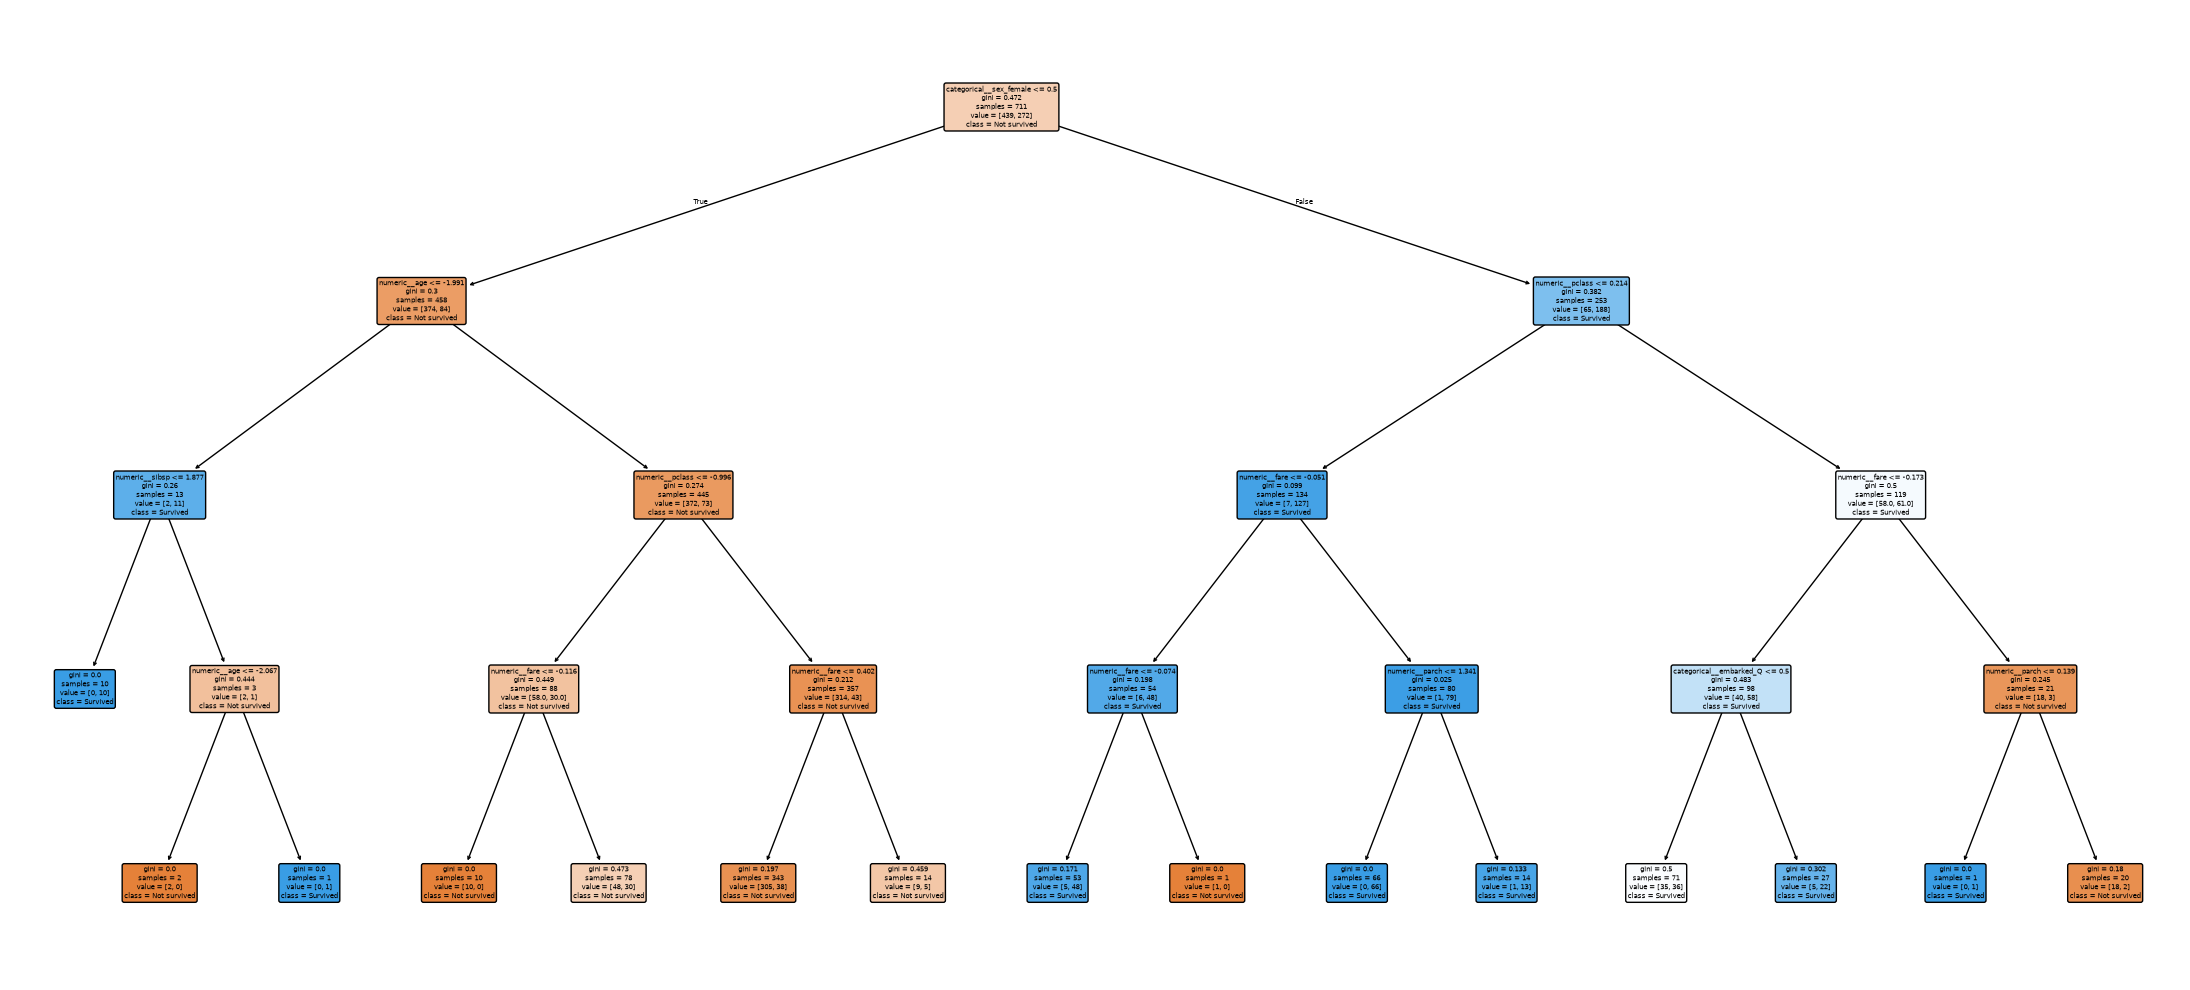

In [4]:
tree_pipeline = pipelines["Decision Tree"]

feature_names = (
    tree_pipeline.named_steps["preprocessing"]
    .get_feature_names_out()
)

plt.figure(figsize=(22, 10))

plot_tree(
    tree_pipeline.named_steps["classifier"],
    feature_names=feature_names,
    class_names=["Not survived", "Survived"],
    filled=True,
    rounded=True
)

plt.tight_layout()
plt.savefig(CHARTS / "decision_tree.png")
plt.show()

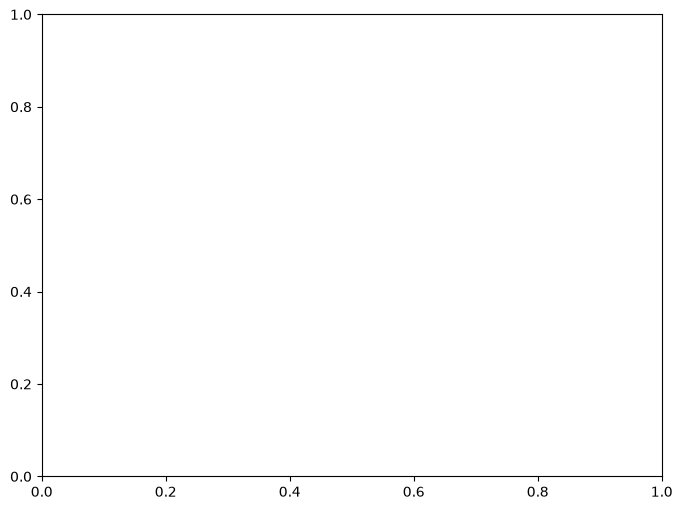

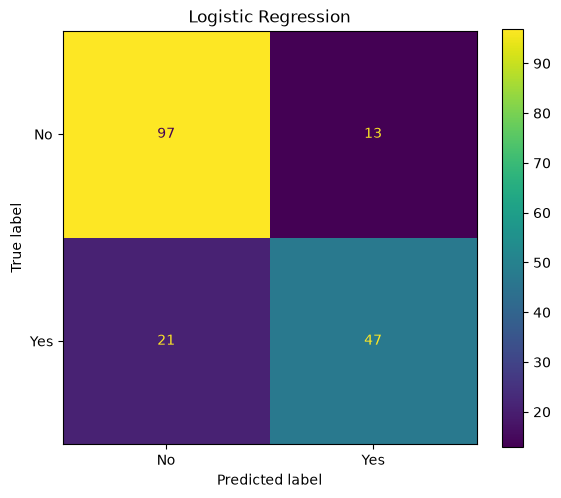

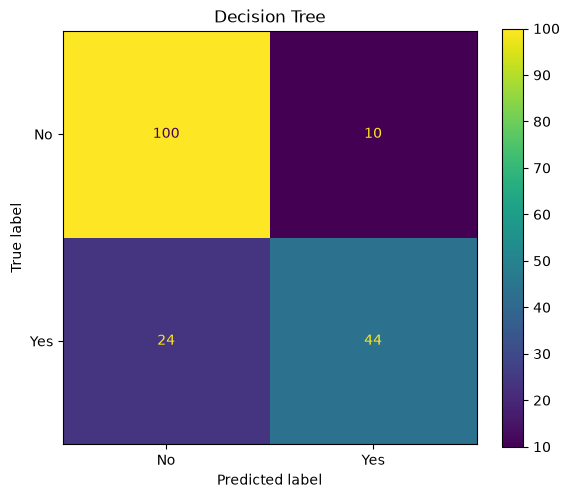

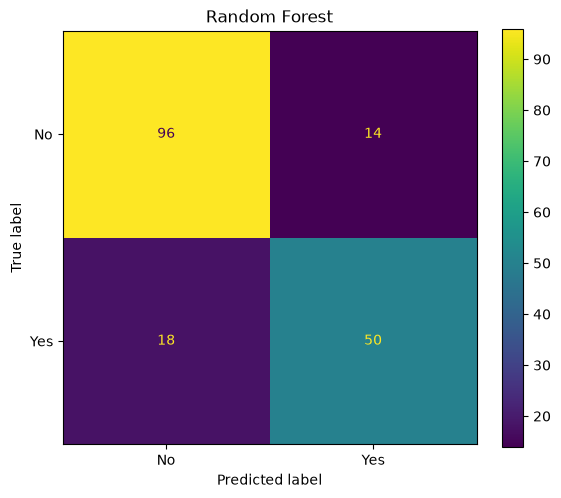

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.808989,0.783333,0.691176,0.734375,0.860963
1,Decision Tree,0.808989,0.814815,0.647059,0.721311,0.856016
2,Random Forest,0.820225,0.781250,0.735294,0.757576,0.817914


In [5]:
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

results = []

fig_roc, ax_roc = plt.subplots(figsize=(8, 6))

for name, pipeline in pipelines.items():
    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1": f1_score(
            y_test, predictions, zero_division=0
        ),
        "AUC": roc_auc_score(y_test, probabilities)
    })

    cm = confusion_matrix(y_test, predictions)

    fig_cm, ax_cm = plt.subplots(figsize=(6, 5))

    ConfusionMatrixDisplay(
        cm, display_labels=["No", "Yes"]
    ).plot(ax=ax_cm)

    ax_cm.set_title(name)
    fig_cm.tight_layout()

    filename = name.lower().replace(" ", "_")
    fig_cm.savefig(CHARTS / f"{filename}_confusion.png")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, probabilities)

    ax_roc.plot(
        fpr, tpr,
        label=f"{name}: AUC={roc_auc_score(y_test, probabilities):.3f}"
    )

ax_roc.plot([0, 1], [0, 1], "--")
ax_roc.set_xlabel("False positive rate")
ax_roc.set_ylabel("True positive rate")
ax_roc.set_title("ROC comparison")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig(CHARTS / "roc_comparison.png")
plt.show()

comparison = pd.DataFrame(results)
display(comparison)

In [6]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

imbalance_models = {
    "Baseline": Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]),

    "Balanced weights": Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]),

    "SMOTE": ImbPipeline([
        ("preprocessing", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", LogisticRegression(max_iter=1000))
    ])
}

imbalance_results = []

for name, pipeline in imbalance_models.items():
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)

    imbalance_results.append({
        "Strategy": name,
        "Precision": precision_score(
            y_test, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, pred, zero_division=0
        ),
        "F1": f1_score(
            y_test, pred, zero_division=0
        )
    })

display(pd.DataFrame(imbalance_results))

,Strategy,Precision,Recall,F1
0,Baseline,0.783333,0.691176,0.734375
1,Balanced weights,0.718310,0.750000,0.733813
2,SMOTE,0.735294,0.735294,0.735294


In [7]:
rf_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(
        oob_score=True,
        bootstrap=True,
        random_state=42
    ))
])

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10, None],
    "classifier__max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-validation F1:", grid.best_score_)

best_rf = grid.best_estimator_

print(
    "OOB score:",
    best_rf.named_steps["classifier"].oob_score_
)

Best parameters: {'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}
Best cross-validation F1: 0.7408312771917277
OOB score: 0.8213783403656821


##  Ticket Fare Prediction Using Linear Regression

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

reg_features = [
    "pclass", "sex", "age", "sibsp",
    "parch", "embarked"
]

X_reg = df[reg_features]
y_reg = df["fare"]

# Split the data: 80% training, 20% testing
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Prepare numerical and categorical columns
reg_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), ["pclass", "age", "sibsp", "parch"]),

    ("categorical", Pipeline([
        ("imputer", SimpleImputer(
            strategy="most_frequent"
        )),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            drop="first",
            sparse_output=False
        ))
    ]), ["sex", "embarked"])
])

# Create the regression pipeline
reg_pipeline = Pipeline([
    ("preprocessing", reg_preprocessor),
    ("regressor", LinearRegression())
])

# Train and predict
reg_pipeline.fit(Xr_train, yr_train)

fare_predictions = reg_pipeline.predict(Xr_test)

print("Linear Regression trained successfully!")
print("First five predicted fares:")
print(fare_predictions[:5])

Linear Regression trained successfully!
First five predicted fares:
[-2.88475489 95.99511931 27.79356729 29.18366602 89.39234588]


In [9]:
mae = mean_absolute_error(
    yr_test, fare_predictions
)

rmse = np.sqrt(
    mean_squared_error(yr_test, fare_predictions)
)

r2 = r2_score(
    yr_test, fare_predictions
)

# Number of test observations
n = len(yr_test)

# Number of features after preprocessing
p = reg_pipeline.named_steps[
    "preprocessing"
].transform(Xr_test).shape[1]

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1) / (n - p - 1)
)

regression_results = pd.DataFrame([{
    "MAE": mae,
    "RMSE": rmse,
    "R²": r2,
    "Adjusted R²": adjusted_r2
}])

display(regression_results)

,MAE,RMSE,R²,Adjusted R²
0,21.138552,41.746502,0.346774,0.319876


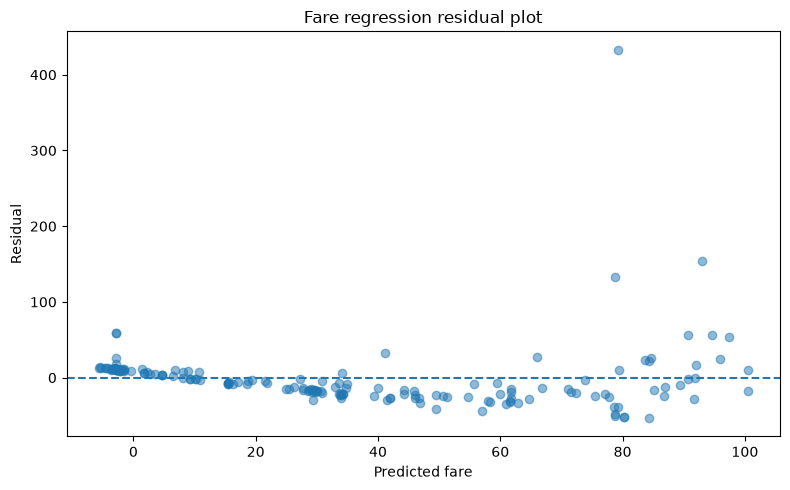

In [10]:
from pathlib import Path

CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

residuals = yr_test - fare_predictions

plt.figure(figsize=(8, 5))

plt.scatter(
    fare_predictions,
    residuals,
    alpha=0.5
)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted fare")
plt.ylabel("Residual")
plt.title("Fare regression residual plot")

plt.tight_layout()
plt.savefig(CHARTS / "regression_residuals.png")
plt.show()

##  Final Model Comparison

In [11]:
print("CLASSIFICATION MODEL COMPARISON")
display(comparison.round(4))

print("REGRESSION MODEL COMPARISON")
display(regression_results.round(4))

CLASSIFICATION MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.8090,0.8148,0.6471,0.7213,0.8560
2,Random Forest,0.8202,0.7812,0.7353,0.7576,0.8179


REGRESSION MODEL COMPARISON


,MAE,RMSE,R²,Adjusted R²
0,21.1386,41.7465,0.3468,0.3199


In [15]:
import joblib

# Select the tuned Random Forest
selected_pipeline = best_rf

# Save the entire fitted pipeline
joblib.dump(
    selected_pipeline,
    "titanic_survival_pipeline.joblib"
)

print("Model saved successfully!")

# Reload the saved pipeline
loaded_pipeline = joblib.load(
    "titanic_survival_pipeline.joblib"
)

# Take five raw test rows
sample = X_test.head(5)

# Compare predictions before and after saving
original_predictions = selected_pipeline.predict(sample)
loaded_predictions = loaded_pipeline.predict(sample)

np.testing.assert_array_equal(
    original_predictions,
    loaded_predictions
)

print("Saved model predictions:", loaded_predictions)
print("Reload verification successful!")

Model saved successfully!
Saved model predictions: [0 0 0 0 0]
Reload verification successful!


In [14]:
# For Logistic Regression
selected_pipeline = pipelines["Logistic Regression"]

# OR for Decision Tree
selected_pipeline = pipelines["Decision Tree"]

# OR for the original Random Forest
selected_pipeline = pipelines["Random Forest"]